# Deep Linear Network の学習後パラメータで局所学習係数を推定する実験

このノートでは、深層線形ネットワークをまず通常の最適化で学習し、その後で学習済みパラメータを初期値として SGLD を回し、損失列から局所学習係数 (RLCT) を推定します。


In [1]:
import copy
from functools import partial

import haiku as hk
import jax
import jax.numpy as jnp
import jax.tree_util as jtree
import numpy as np
import optax
import matplotlib.pyplot as plt

from dln import create_dln_model, mse_loss, true_dln_learning_coefficient
from sgld_utils import SGLDConfig, run_sgld_and_estimate_learning_coefficient


In [2]:
# 実験設定
seed = 0
input_dim = 2
hidden_dim = 4
output_dim = 2
layer_widths = [hidden_dim, output_dim]
true_rank = 1

num_train = 512
train_batch_size = 64
num_train_steps = 4000
learning_rate = 1e-2

sgld_num_steps = 5000
sgld_batch_size = 64
sgld_epsilon = 5e-6
sgld_gamma = 200.0
sgld_burn_in = 1000
num_extrapolation = 7

rng = jax.random.PRNGKey(seed)
model = create_dln_model(layer_widths, sigma=0.1)
example_x = jnp.ones((1, input_dim))


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [3]:
def make_rank_one_teacher_params(model, rngkey, input_dim, hidden_dim, output_dim, strength=2.0):
    # Construct teacher parameters whose end-to-end map has rank 1.
    params = model.init(rngkey, jnp.ones((1, input_dim)))
    params = hk.data_structures.to_mutable_dict(params)

    w1_shape = params['deep_linear_network/linear']['w'].shape
    w2_shape = params['deep_linear_network/linear_1']['w'].shape

    left_1 = jnp.zeros((w1_shape[0], 1), dtype=jnp.float32)
    right_1 = jnp.zeros((1, w1_shape[1]), dtype=jnp.float32)
    left_1 = left_1.at[0, 0].set(strength)
    right_1 = right_1.at[0, :min(w1_shape[1], 4)].set(jnp.array([1.0, -0.7, 0.4, 0.0], dtype=jnp.float32)[:min(w1_shape[1], 4)])
    w1 = left_1 @ right_1

    left_2 = jnp.zeros((w2_shape[0], 1), dtype=jnp.float32)
    right_2 = jnp.zeros((1, w2_shape[1]), dtype=jnp.float32)
    left_2 = left_2.at[:min(w2_shape[0], 4), 0].set(jnp.array([1.2, -0.5, 0.8, 0.0], dtype=jnp.float32)[:min(w2_shape[0], 4)])
    right_2 = right_2.at[0, :min(w2_shape[1], 2)].set(jnp.array([1.0, -0.8], dtype=jnp.float32)[:min(w2_shape[1], 2)])
    w2 = left_2 @ right_2

    params['deep_linear_network/linear']['w'] = w1
    params['deep_linear_network/linear_1']['w'] = w2
    return hk.data_structures.to_immutable_dict(params)


def generate_linear_regression_data(rngkey, teacher_params, num_samples, input_dim, noise_std=0.03):
    rngkey, x_key, noise_key = jax.random.split(rngkey, 3)
    x = jax.random.normal(x_key, (num_samples, input_dim))
    y_clean = model.apply(teacher_params, x)
    y = y_clean + noise_std * jax.random.normal(noise_key, y_clean.shape)
    return rngkey, x, y, y_clean


@jax.jit
def train_loss(params, x, y):
    return mse_loss(params, model, x, y)


def tree_l2_distance(tree_a, tree_b):
    leaves_a = jtree.tree_leaves(tree_a)
    leaves_b = jtree.tree_leaves(tree_b)
    return float(jnp.sqrt(sum(jnp.sum((a - b) ** 2) for a, b in zip(leaves_a, leaves_b))))


In [4]:
# 低ランク教師モデルと学習データを作る
rng, teacher_key, data_key, init_key = jax.random.split(rng, 4)
teacher_params = make_rank_one_teacher_params(model, teacher_key, input_dim, hidden_dim, output_dim)
rng, x_train, y_train, y_clean = generate_linear_regression_data(data_key, teacher_params, num_train, input_dim)
init_params = model.init(init_key, example_x)

true_lambda, multiplicity = true_dln_learning_coefficient(
    true_rank=true_rank,
    layer_widths=layer_widths,
    input_dim=input_dim,
)
print(f"theoretical lambda = {true_lambda}, multiplicity = {multiplicity}")
print(f"initial train loss = {float(train_loss(init_params, x_train, y_train)):.6f}")


theoretical lambda = 2.0, multiplicity = 1.0
initial train loss = 13.091926


In [5]:
# 通常の最適化で線形NNを学習する
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(init_params)
params = init_params
loss_history = []

@jax.jit
def train_step(params, opt_state, x, y):
    loss_value, grads = jax.value_and_grad(train_loss)(params, x, y)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss_value

for step in range(num_train_steps):
    batch_indices = np.random.choice(num_train, train_batch_size, replace=False)
    x_batch = x_train[batch_indices]
    y_batch = y_train[batch_indices]
    params, opt_state, batch_loss = train_step(params, opt_state, x_batch, y_batch)
    loss_history.append(float(batch_loss))

trained_params = copy.deepcopy(params)
final_loss = float(train_loss(trained_params, x_train, y_train))
print(f"final train loss = {final_loss:.6f}")
print(f"distance from init = {tree_l2_distance(init_params, trained_params):.6f}")
print(f"distance from teacher = {tree_l2_distance(teacher_params, trained_params):.6f}")


final train loss = 0.000932
distance from init = 3.070808
distance from teacher = 5.859273


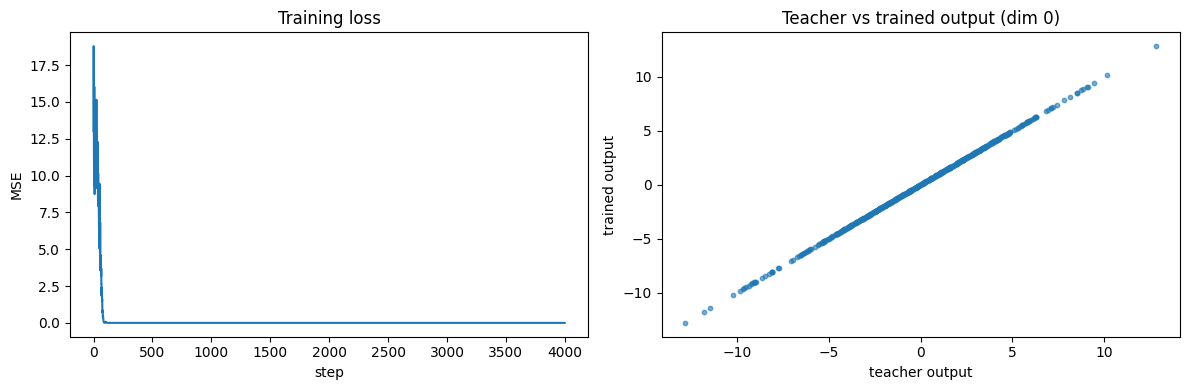

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_history)
axes[0].set_title('Training loss')
axes[0].set_xlabel('step')
axes[0].set_ylabel('MSE')

teacher_pred = model.apply(teacher_params, x_train)
trained_pred = model.apply(trained_params, x_train)
axes[1].scatter(np.asarray(teacher_pred[:, 0]), np.asarray(trained_pred[:, 0]), s=10, alpha=0.6)
axes[1].set_title('Teacher vs trained output (dim 0)')
axes[1].set_xlabel('teacher output')
axes[1].set_ylabel('trained output')
plt.tight_layout()


In [8]:
# 学習済みパラメータを中心に SGLD を走らせて RLCT を推定する
sgld_config = SGLDConfig(
    epsilon=sgld_epsilon,
    gamma=sgld_gamma,
    num_steps=sgld_num_steps,
    batch_size=sgld_batch_size,
)

loss_fn = lambda param, inputs, targets: mse_loss(param, model, inputs, targets)
itemp = 1.0 / np.log(num_train)
sgld_logging_period = max(1, sgld_num_steps // 20)

print("Starting SGLD for RLCT estimation...")
print(f"num_steps={sgld_num_steps}, burn_in={sgld_burn_in}, logging_period={sgld_logging_period}")

estimated_lambda, sgld_loss_trace, distances, accept_probs = run_sgld_and_estimate_learning_coefficient(
    rngkey=rng,
    loss_fn=loss_fn,
    sgld_config=sgld_config,
    param_init=trained_params,
    x_train=x_train,
    y_train=y_train,
    itemp=itemp,
    burn_in=sgld_burn_in,
    num_extrapolation=num_extrapolation,
    trace_batch_loss=False,
    compute_distance=True,
    compute_mala_acceptance=False,
    verbose=True,
    logging_period=sgld_logging_period,
)

print(f"Finished SGLD. collected {len(sgld_loss_trace)} loss values")
print(f"estimated lambda = {float(estimated_lambda):.6f}")
print(f"theoretical lambda = {true_lambda:.6f}")
print(f"absolute error = {abs(float(estimated_lambda) - true_lambda):.6f}")


Starting SGLD for RLCT estimation...
num_steps=5000, burn_in=1000, logging_period=250
Step 0, loss: 0.0009318353841081262
Step 250, loss: 0.004190500825643539
Step 500, loss: 0.0035318194422870874
Step 750, loss: 0.005216284655034542
Step 1000, loss: 0.01414596475660801
Step 1250, loss: 0.002549222204834223
Step 1500, loss: 0.01570925861597061
Step 1750, loss: 0.01293942704796791
Step 2000, loss: 0.006121205165982246
Step 2250, loss: 0.005036256276071072
Step 2500, loss: 0.008553804829716682
Step 2750, loss: 0.003926389385014772
Step 3000, loss: 0.022021150216460228
Step 3250, loss: 0.03265271335840225
Step 3500, loss: 0.018340662121772766
Step 3750, loss: 0.014673871919512749
Step 4000, loss: 0.01365403737872839
Step 4250, loss: 0.00824930239468813
Step 4500, loss: 0.014123301953077316
Step 4750, loss: 0.006907186005264521
Finished SGLD. collected 5000 loss values
estimated lambda = 0.388999
theoretical lambda = 2.000000
absolute error = 1.611001


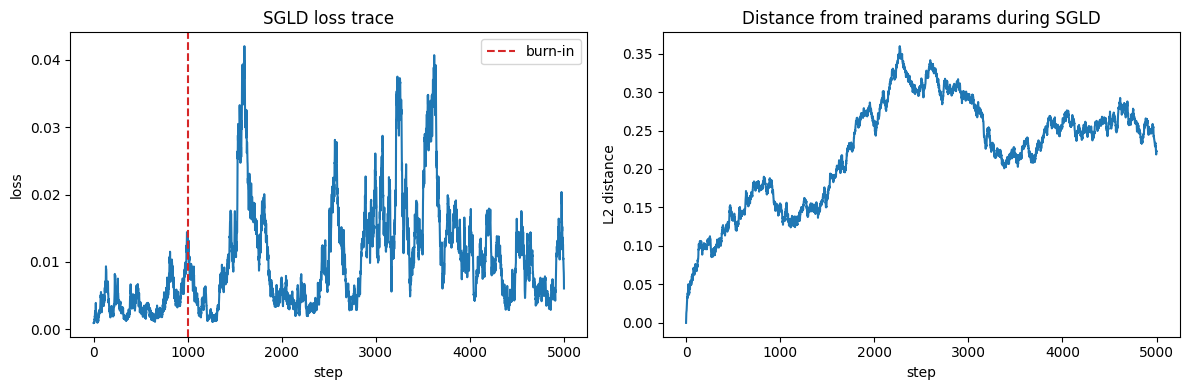

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.asarray(sgld_loss_trace))
axes[0].axvline(sgld_burn_in, color='tab:red', linestyle='--', label='burn-in')
axes[0].set_title('SGLD loss trace')
axes[0].set_xlabel('step')
axes[0].set_ylabel('loss')
axes[0].legend()

axes[1].plot(np.asarray(distances))
axes[1].set_title('Distance from trained params during SGLD')
axes[1].set_xlabel('step')
axes[1].set_ylabel('L2 distance')
plt.tight_layout()


## メモ

- `true_rank = 1` の教師写像を使って、特異性のある深層線形モデルの設定を作っています。
- 先に Adam で学習してから、その学習済みパラメータを `param_init` として SGLD に渡しています。
- `estimated_lambda` は有限サンプル・有限ステップの推定値なので、`sgld_num_steps` や `sgld_gamma` を変えると値が動きます。
- 推定が不安定なときは `num_train`, `sgld_num_steps`, `sgld_burn_in` を増やして確認してください。
